# Customer Churn Prediction using Machine Learning

## Business Problem

Customer churn is one of the biggest challenges faced by telecom companies. Predicting customers who are likely to leave helps businesses improve customer retention and reduce revenue loss.

## Objective

Build and compare multiple machine learning models to predict customer churn using demographic, service, and billing information.

## Workflow

- Import Libraries
- Load Dataset
- Data Exploration
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Encode Categorical Variables
- Feature Scaling
- Model Training
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance
- Customer Prediction

# 1. Import Required Libraries

In [81]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [82]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# 3. Data Understanding

In [83]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [84]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [86]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [87]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [88]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 4. Data Cleaning

In [89]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [90]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [91]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [92]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [93]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [94]:
df.dropna(inplace=True)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [96]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [97]:
print(df.shape)

(7032, 21)


# 5. Exploratory Data Analysis (EDA)

In [98]:
# 5.1 Target Variable Analysis

df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [99]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

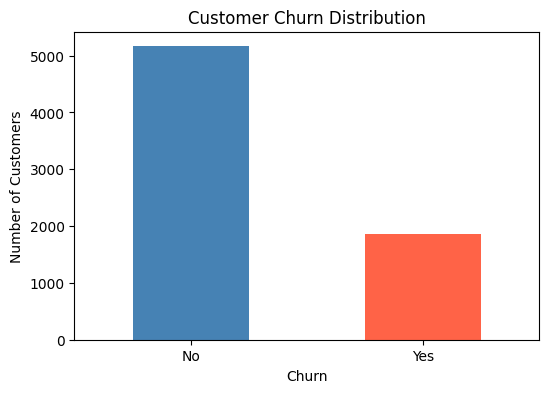

In [100]:
# Churn Distribution
plt.figure(figsize=(6,4))
df["Churn"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [101]:
# 5.2 Numerical Features Analysis

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


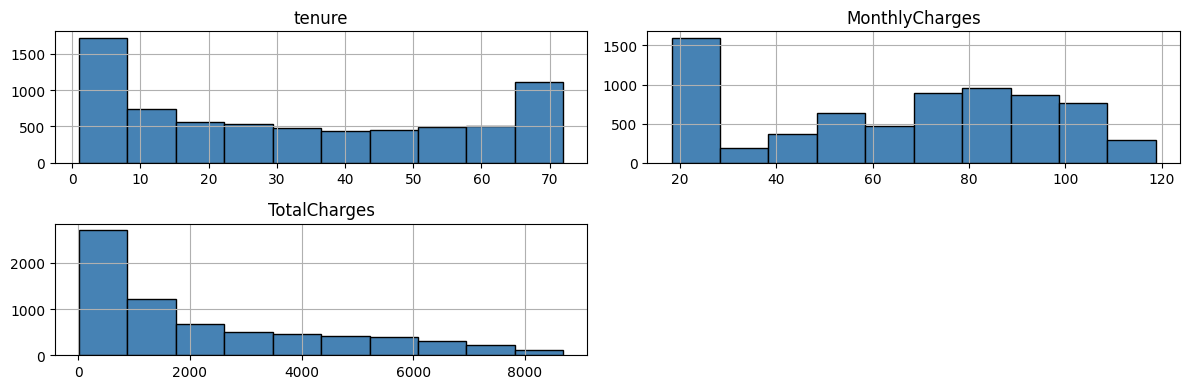

In [102]:
# Distribution of Numerical Features
df[numerical_features].hist(
    figsize=(12,4),
    color="steelblue",
    edgecolor="black"
)
plt.tight_layout()
plt.show()

In [103]:
# 5.3 Correlation Analysis

# Correlation Between Numerical Features
correlation = df[numerical_features].corr()
correlation

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


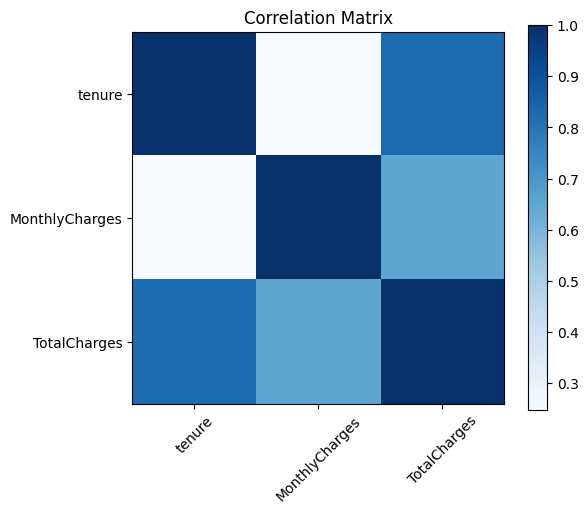

In [104]:
plt.figure(figsize=(6,5))
plt.imshow(correlation, cmap="Blues")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.title("Correlation Matrix")
plt.show()

In [105]:
# 5.4 Categorical Features Analysis

# Gender vs Churn
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


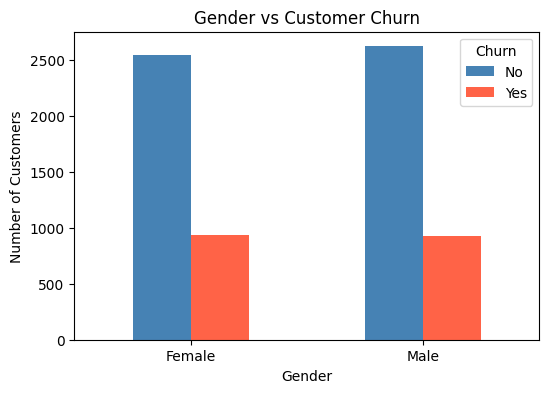

In [106]:
pd.crosstab(df["gender"], df["Churn"]).plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue","tomato"]
)
plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [107]:
# Contract Type vs Churn
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


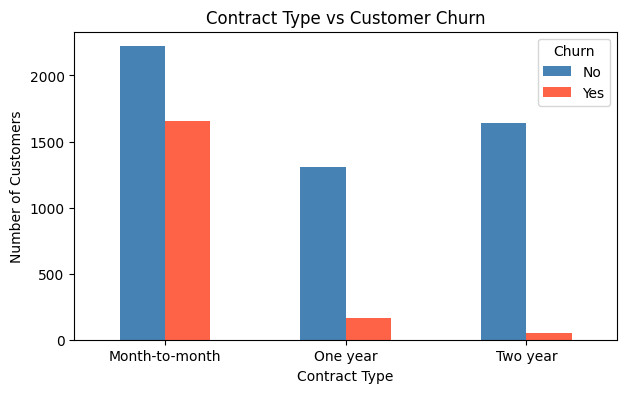

In [108]:
pd.crosstab(df["Contract"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,4),
    color=["steelblue", "tomato"]
)
plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [109]:
# Internet Service vs Churn
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


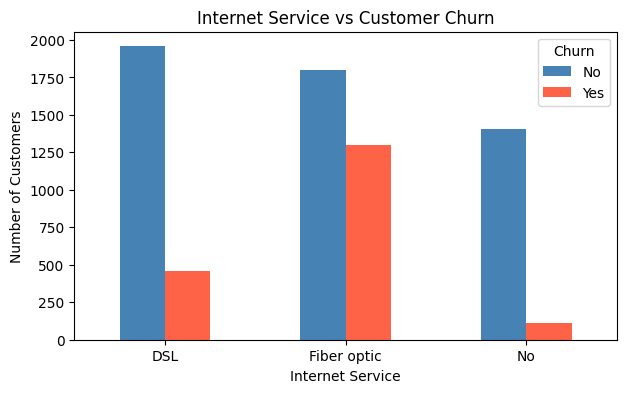

In [110]:
pd.crosstab(df["InternetService"], df["Churn"]).plot(
    kind="bar",
    figsize=(7,4),
    color=["steelblue","tomato"]
)
plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [111]:
# Payment Method vs Churn
pd.crosstab(df["PaymentMethod"], df["Churn"])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


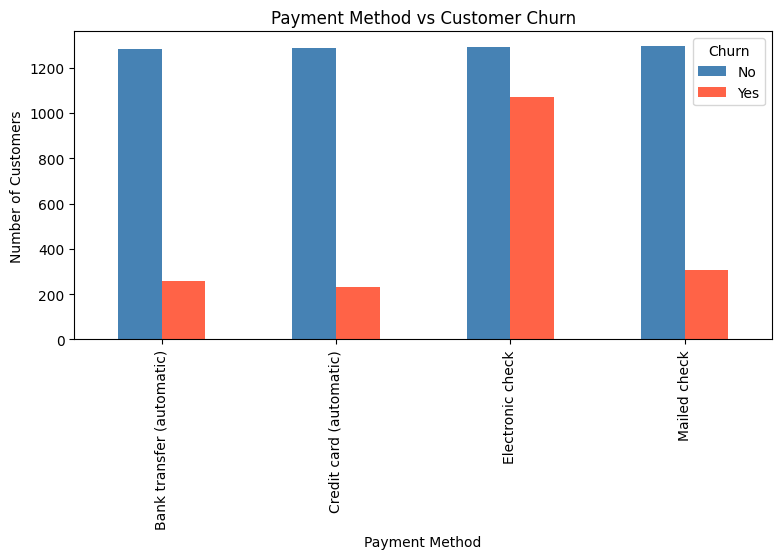

In [112]:
pd.crosstab(df["PaymentMethod"], df["Churn"]).plot(
    kind="bar",
    figsize=(9,4),
    color=["steelblue","tomato"]
)
plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

In [113]:
# Senior Citizen vs Churn
pd.crosstab(df["SeniorCitizen"], df["Churn"])

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


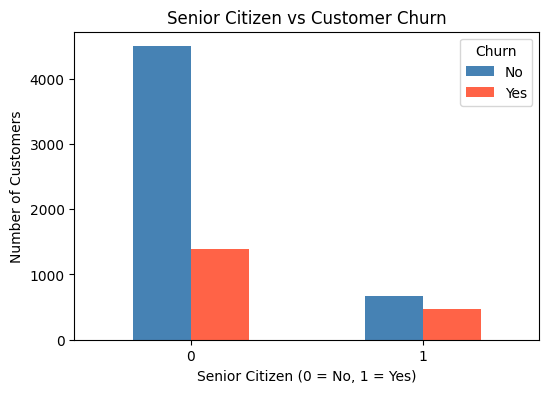

In [114]:
pd.crosstab(df["SeniorCitizen"], df["Churn"]).plot(
    kind="bar",
    figsize=(6,4),
    color=["steelblue","tomato"]
)
plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

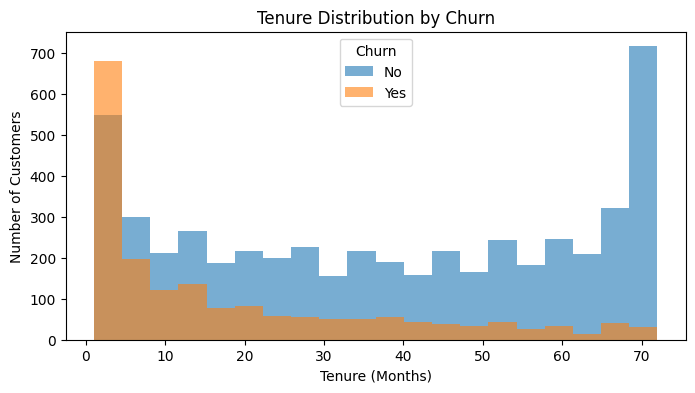

In [115]:
# 5.5 Numerical Features vs Churn

# Tenure vs Churn
plt.figure(figsize=(8,4))

for churn in ["No", "Yes"]:
    plt.hist(
        df[df["Churn"] == churn]["tenure"],
        bins=20,
        alpha=0.6,
        label=churn
    )
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

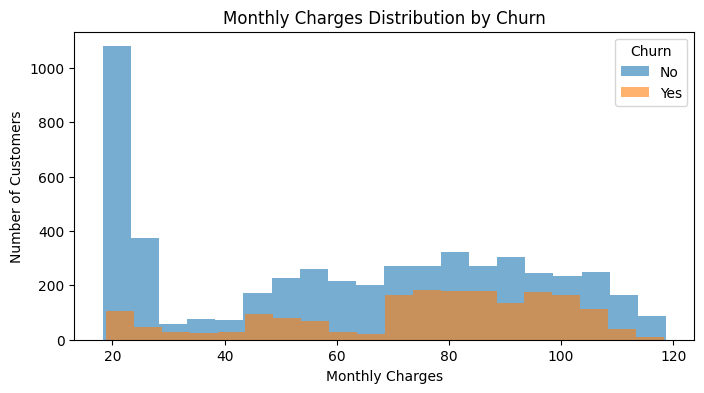

In [117]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,4))

for churn in ["No", "Yes"]:
    plt.hist(
        df[df["Churn"] == churn]["MonthlyCharges"],
        bins=20,
        alpha=0.6,
        label=churn
    )
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

## Key Insights from EDA

- Most customers did not churn, indicating a moderately imbalanced dataset.
- Customers with month-to-month contracts showed a higher churn rate than those with one-year or two-year contracts.
- Customers with shorter tenure were more likely to churn.
- Higher monthly charges were associated with increased churn.
- Internet service type and payment method also influenced churn behavior.

# 6. Data Preprocessing

In [118]:
# 6.1 Drop Unnecessary Columns

# customerID is only an identifier and does not help in prediction
df = df.drop("customerID", axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [119]:
# 6.2 Separate Features and Target Variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7032, 19)
Target Shape: (7032,)


In [122]:
# 6.3 Identify Categorical and Numerical Features

categorical_columns = X.select_dtypes(include="object").columns.tolist()
numerical_columns = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features:")
print(categorical_columns)

print("\nNumerical Features:")
print(numerical_columns)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


# 7. Feature Engineering

In [123]:
# 7.1 Encode Categorical Variables

X = pd.get_dummies(X, drop_first=True)
print("Shape after Encoding:", X.shape)

Shape after Encoding: (7032, 30)


In [124]:
# 7.2 Encode Target Variable

y = y.map({"No": 0, "Yes": 1})
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

# 8. Feature Scaling

In [125]:
# 8.1 Standardize Numerical Features

scaler = StandardScaler()
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.440327,-1.280248,-1.161694,-0.994194,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,-0.440327,0.064303,-0.260878,-0.173740,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,-0.440327,-1.239504,-0.363923,-0.959649,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,-0.440327,0.512486,-0.747850,-0.195248,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,-0.440327,-1.239504,0.196178,-0.940457,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


# 9. Train-Test Split

In [126]:
# 9.1 Split Features and Target into Training and Testing Sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (5625, 30)
Testing Features Shape  : (1407, 30)
Training Labels Shape   : (5625,)
Testing Labels Shape    : (1407,)


# 10. Model Training

### Logistic Regression

In [135]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [136]:
y_pred_log = log_model.predict(X_test)

### Decision Tree

In [137]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)
dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [138]:
y_pred_dt = dt_model.predict(X_test)

### Random Forest

In [139]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [140]:
y_pred_rf = rf_model.predict(X_test)

### K-Nearest Neighbors (KNN)

In [141]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [142]:
y_pred_knn = knn_model.predict(X_test)

# 11. Model Evaluation

In [143]:
# Function to evaluate any classification model

def evaluate_model(model_name, y_true, y_pred):

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred))

In [144]:
# Logistic Regression Evaluation

evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log
)

Logistic Regression
Accuracy : 0.8038
Precision: 0.6494
Recall   : 0.5695
F1 Score : 0.6068

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [145]:
# Decision Tree Evaluation

evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt
)

Decision Tree
Accuracy : 0.7783
Precision: 0.5807
Recall   : 0.5963
F1 Score : 0.5884

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



In [146]:
# Random Forest Evaluation

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
Accuracy : 0.7896
Precision: 0.6258
Recall   : 0.5187
F1 Score : 0.5673

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [147]:
# KNN Evaluation

evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    y_pred_knn
)

K-Nearest Neighbors
Accuracy : 0.7605
Precision: 0.5486
Recall   : 0.5588
F1 Score : 0.5536

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1033
           1       0.55      0.56      0.55       374

    accuracy                           0.76      1407
   macro avg       0.69      0.70      0.69      1407
weighted avg       0.76      0.76      0.76      1407



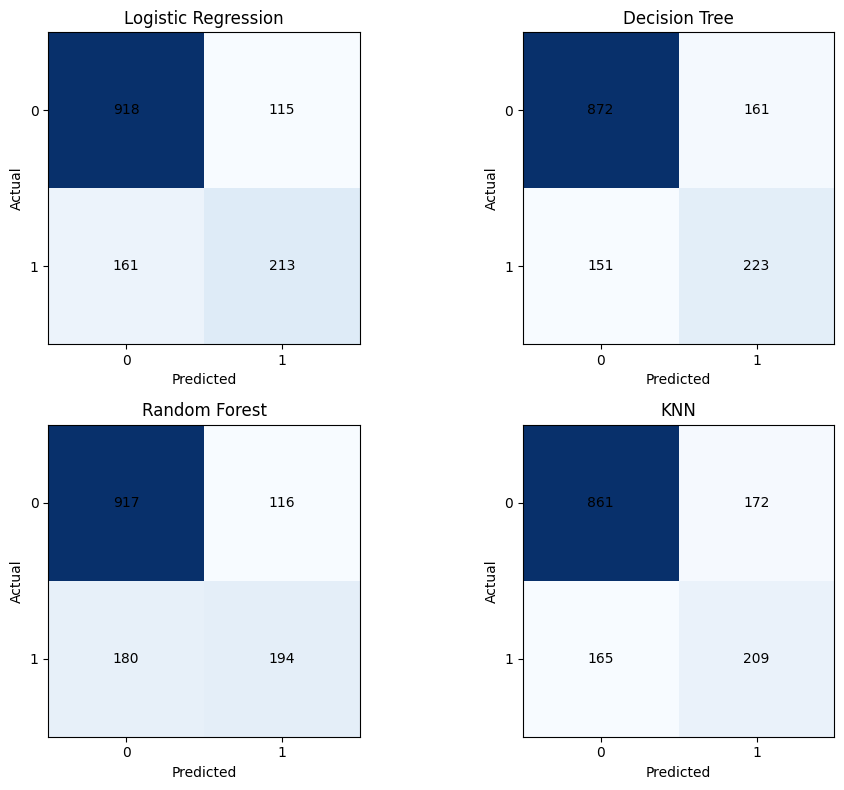

In [154]:
# 11.1 Confusion Matrices

# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
models = {
    "Logistic Regression": y_pred_log,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}
for ax, (model_name, prediction) in zip(axes.flatten(), models.items()):

    cm = confusion_matrix(y_test, prediction)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="black"
            )
plt.tight_layout()
plt.show()

# 12. Model Comparison

In [155]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.649390,0.569519,0.606838
1,Decision Tree,0.778252,0.580729,0.596257,0.588391
2,Random Forest,0.789623,0.625806,0.518717,0.567251
3,KNN,0.760483,0.548556,0.558824,0.553642


In [156]:
results.sort_values(
    by="F1 Score",
    ascending=False,
    inplace=True
)
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.803838,0.649390,0.569519,0.606838
1,Decision Tree,0.778252,0.580729,0.596257,0.588391
2,Random Forest,0.789623,0.625806,0.518717,0.567251
3,KNN,0.760483,0.548556,0.558824,0.553642


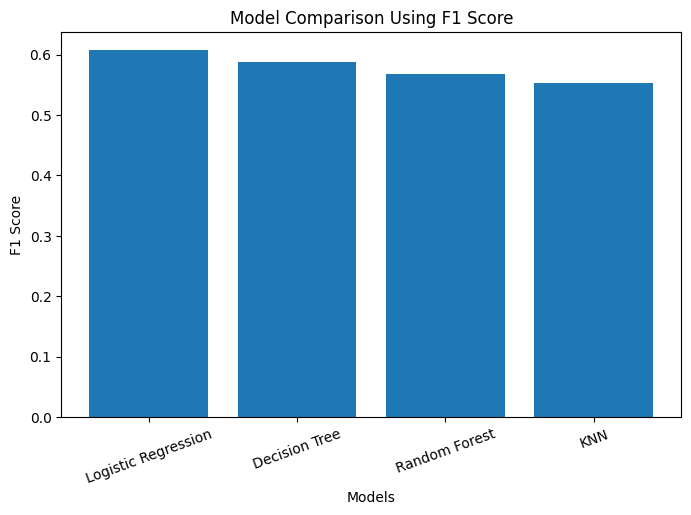

In [157]:
plt.figure(figsize=(8,5))
plt.bar(
    results["Model"],
    results["F1 Score"]
)
plt.title("Model Comparison Using F1 Score")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

# 13. Hyperparameter Tuning

In [159]:
# 13.1 Hyperparameter Tuning using GridSearchCV

# Hyperparameter values to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [160]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [161]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [167]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'C': 1, 'solver': 'liblinear'}

Best Cross Validation F1 Score:
0.5959270716966045


In [168]:
best_log_model = grid_search.best_estimator_

In [169]:
y_pred_best = best_log_model.predict(X_test)

In [170]:
evaluate_model(
    "Tuned Logistic Regression",
    y_test,
    y_pred_best
)

Tuned Logistic Regression
Accuracy : 0.8031
Precision: 0.6474
Recall   : 0.5695
F1 Score : 0.6060

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [171]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Before Tuning)",
        "Logistic Regression (After Tuning)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_best)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_best)
    ]
})
comparison

,Model,Accuracy,F1 Score
0,Logistic Regression (Before Tuning),0.803838,0.606838
1,Logistic Regression (After Tuning),0.803127,0.605974


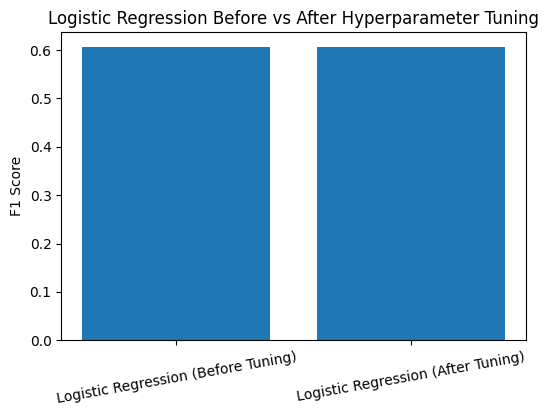

In [172]:
plt.figure(figsize=(6,4))
plt.bar(
    comparison["Model"],
    comparison["F1 Score"]
)
plt.title("Logistic Regression Before vs After Hyperparameter Tuning")
plt.ylabel("F1 Score")
plt.xticks(rotation=10)
plt.show()

# 14. Feature Importance

In [173]:
# Extract feature names
feature_names = X.columns

In [174]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_log_model.coef_[0]
})
importance["Absolute"] = importance["Coefficient"].abs()
importance = importance.sort_values(
    by="Absolute",
    ascending=False
)
importance.head(10)

,Feature,Coefficient,Absolute
25,Contract_Two year,-1.364891,1.364891
1,tenure,-1.351364,1.351364
10,InternetService_Fiber optic,0.870776,0.870776
7,PhoneService_Yes,-0.759259,0.759259
24,Contract_One year,-0.752252,0.752252
3,TotalCharges,0.640406,0.640406
13,OnlineSecurity_Yes,-0.422888,0.422888
19,TechSupport_Yes,-0.381014,0.381014
28,PaymentMethod_Electronic check,0.375878,0.375878
9,MultipleLines_Yes,0.313710,0.313710


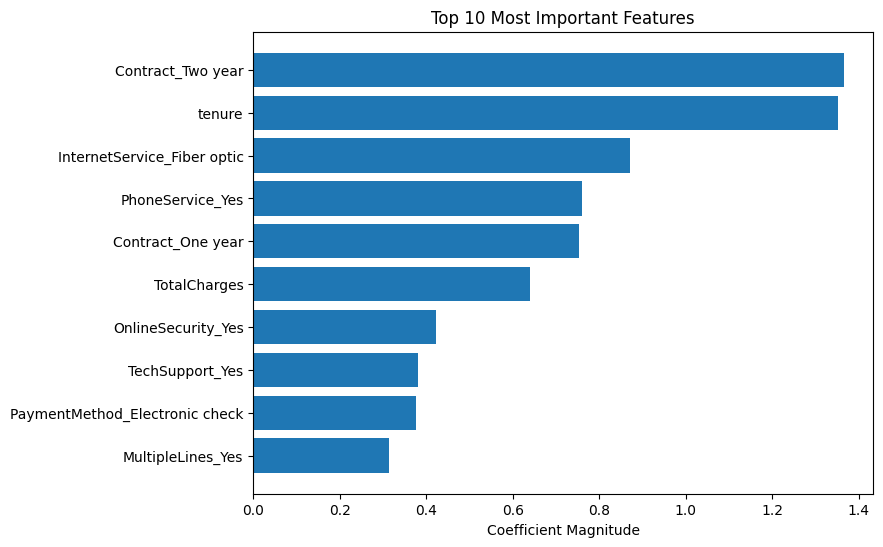

In [175]:
plt.figure(figsize=(8,6))
plt.barh(
    importance["Feature"][:10],
    importance["Absolute"][:10]
)
plt.title("Top 10 Most Important Features")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()
plt.show()

# 15. Predict Customer Churn

In [176]:
sample = X_test.iloc[[0]]
prediction = best_log_model.predict(sample)[0]
if prediction == 1:
    print("Prediction: Customer is likely to Churn.")
else:
    print("Prediction: Customer is likely to Stay.")

Prediction: Customer is likely to Stay.


# 16. Save Trained Model

In [177]:
import joblib

In [178]:
joblib.dump(best_log_model, "customer_churn_model.pkl")
print("Model saved successfully.")

Model saved successfully.


# 17. Conclusion

### Key Findings

- The dataset contained 7,043 customer records with no missing or duplicate values.
- Exploratory Data Analysis revealed that contract type, tenure, and monthly charges strongly influence customer churn.
- Categorical variables were encoded, numerical features were scaled, and the dataset was prepared for machine learning.
- Four classification models were evaluated: Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors.
- Logistic Regression achieved the best overall performance with approximately 80% accuracy and the highest F1 Score.
- Hyperparameter tuning confirmed that the default Logistic Regression configuration was already near optimal for this dataset.

### Business Recommendation

Customers with short contract durations and higher monthly charges are more likely to churn. Businesses can improve customer retention by offering long-term contract incentives and personalized retention strategies for high-risk customers identified by the model.